# AV1 — Aprendizado de Máquina (IDP, 2026.1)

**Prof.:** Klayton R. Castro  
**Aluno:** Samuel Abrão  
**Dataset:** Air Quality UCI  
**Alvo:** `CO(GT)` (regressão)  

Pipeline completo: EDA → tratamento → modelagem → escolha → exportação (.pkl).

## Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Questão 1 — Notebook de Treinamento e Pipeline
### a) Análise Exploratória

In [2]:
DATASET_PATH = Path('..') / 'dataset' / 'AirQualityUCI.csv'
df = pd.read_csv(DATASET_PATH, sep=';', decimal=',')
# Remove colunas/linhas totalmente vazias (o CSV original tem 2 colunas a mais
# e linhas em branco ao final).
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')
print(f'Shape: {df.shape}')
df.head()

Shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


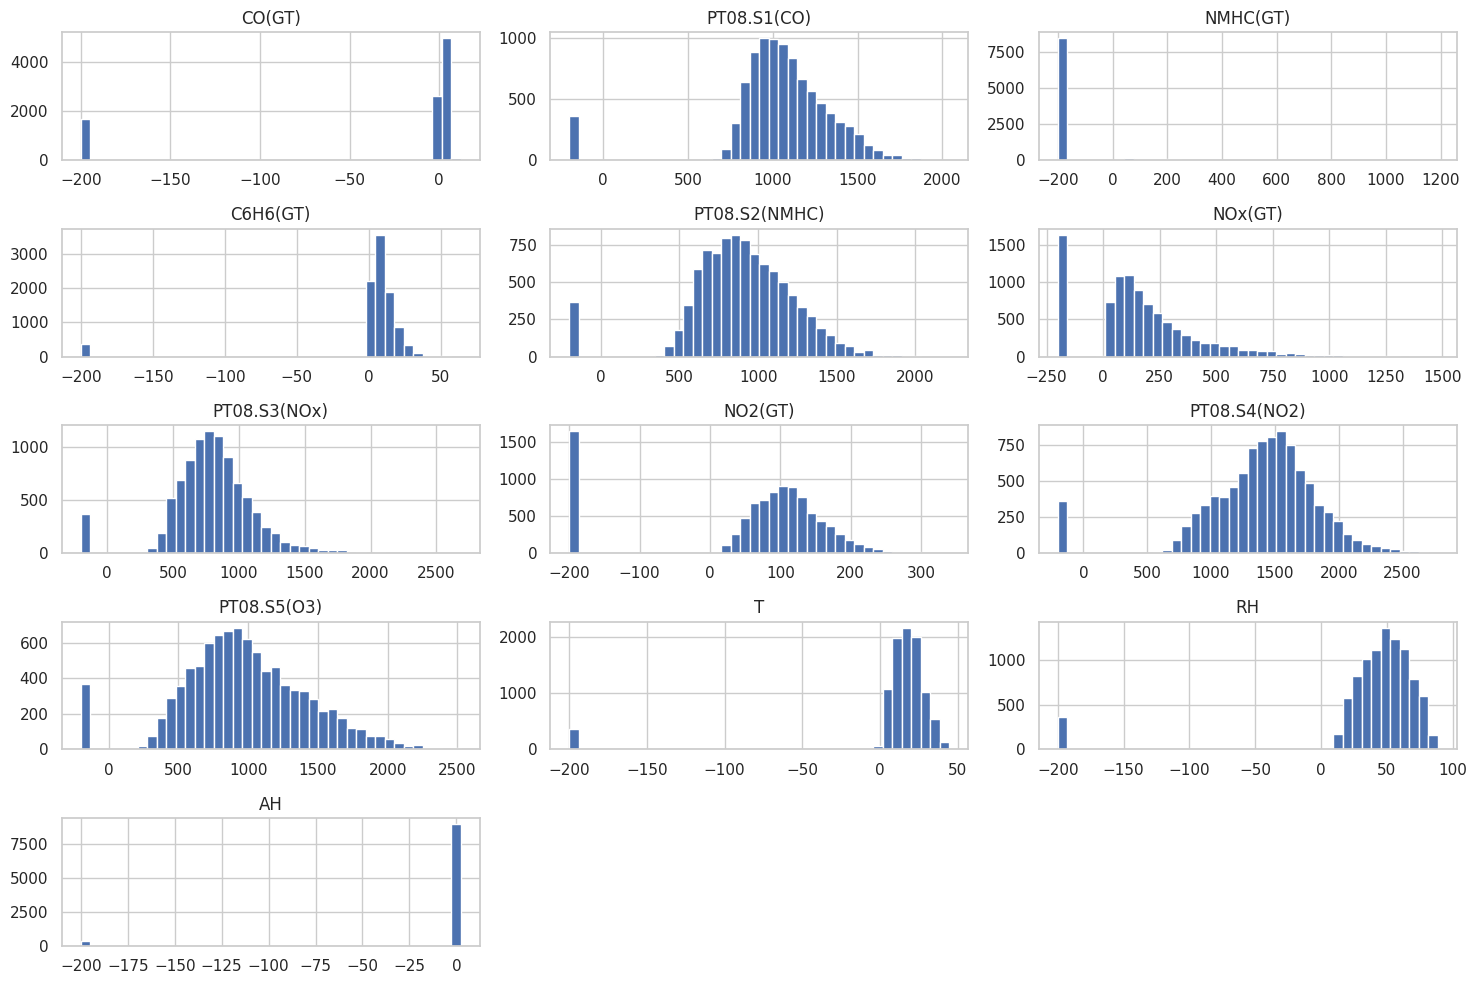

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(nrows=(len(numeric_cols) + 2) // 3, ncols=3, figsize=(15, 10))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].hist(ax=ax, bins=40)
    ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

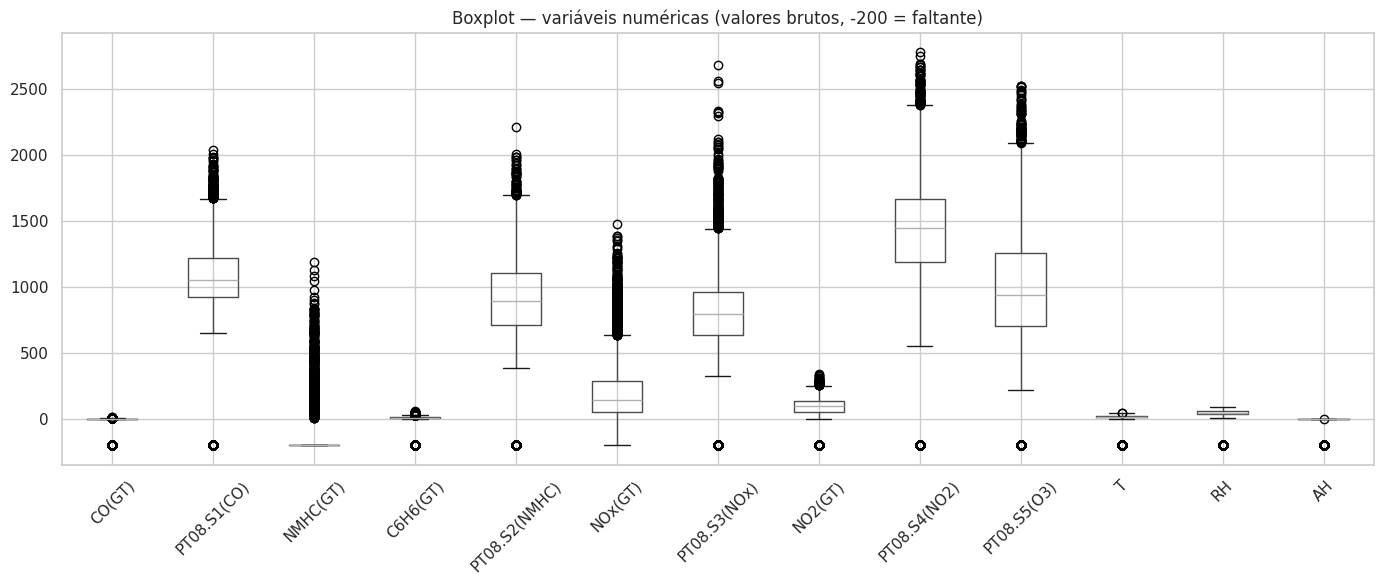

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
df[numeric_cols].boxplot(ax=ax, rot=45)
ax.set_title('Boxplot — variáveis numéricas (valores brutos, -200 = faltante)')
plt.tight_layout()
plt.show()

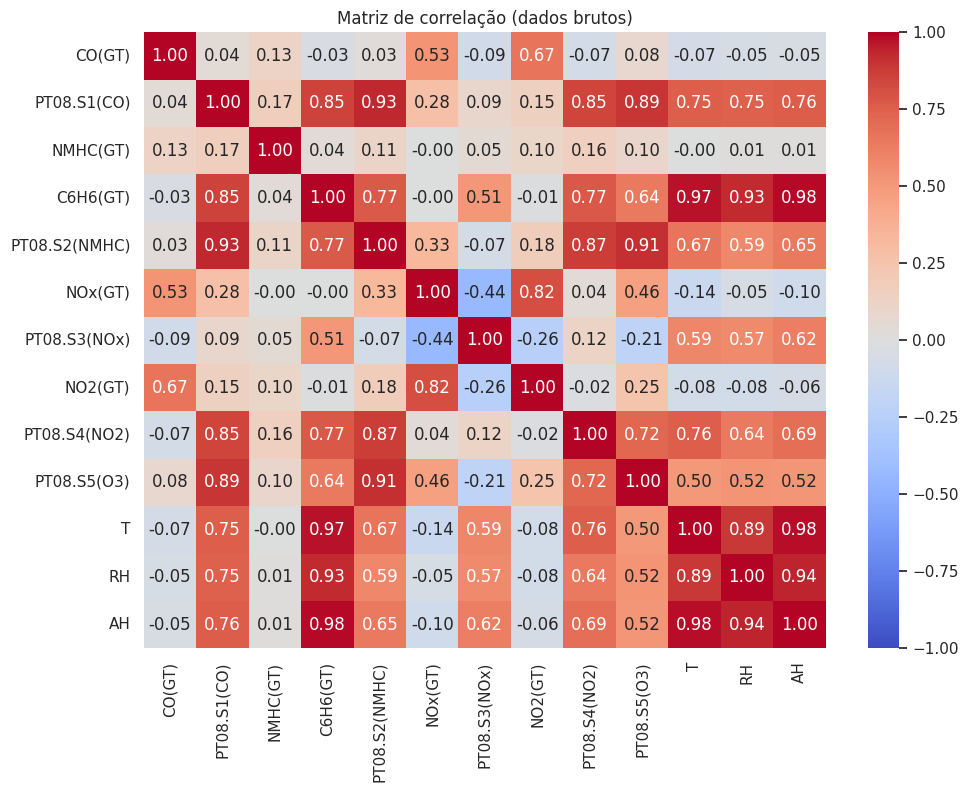

In [7]:
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlação (dados brutos)')
plt.show()

### b) Qualidade dos dados

O dataset usa `-200` como *sentinel* de valor ausente e os decimais vêm com vírgula. Vamos converter tipos, substituir `-200` por `NaN`, descartar `NMHC(GT)` (muitos ausentes) e eliminar registros remanescentes com nulos.

In [8]:
print('Contagem de -200 por coluna (sentinel de missing):')
for col in df.select_dtypes(include=[np.number]).columns:
    count = (df[col] == -200).sum()
    if count:
        print(f'  {col}: {count}')


Contagem de -200 por coluna (sentinel de missing):
  CO(GT): 1683
  PT08.S1(CO): 366
  NMHC(GT): 8443
  C6H6(GT): 366
  PT08.S2(NMHC): 366
  NOx(GT): 1639
  PT08.S3(NOx): 366
  NO2(GT): 1642
  PT08.S4(NO2): 366
  PT08.S5(O3): 366
  T: 366
  RH: 366
  AH: 366


In [9]:
# Conversão e limpeza
df_clean = df.copy()
df_clean['DateTime'] = pd.to_datetime(
    df_clean['Date'] + ' ' + df_clean['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce',
)
df_clean = df_clean.drop(columns=['Date', 'Time'])
df_clean = df_clean.replace(-200, np.nan)

missing_pct = df_clean.isna().mean().sort_values(ascending=False) * 100
print('Percentual de NaN por coluna:')
print(missing_pct.round(2))

Percentual de NaN por coluna:
NMHC(GT)         90.23
CO(GT)           17.99
NO2(GT)          17.55
NOx(GT)          17.52
C6H6(GT)          3.91
PT08.S1(CO)       3.91
PT08.S2(NMHC)     3.91
PT08.S3(NOx)      3.91
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
T                 3.91
RH                3.91
AH                3.91
DateTime          0.00
dtype: float64


In [10]:
# NMHC(GT) tem >90% de NaN — descartamos para não viesar o modelo.
df_clean = df_clean.drop(columns=['NMHC(GT)'])
df_clean = df_clean.dropna()
print(f'Shape após limpeza: {df_clean.shape}')
df_clean.describe().T

Shape após limpeza: (6941, 13)


,count,mean,min,25%,50%,75%,max,std
CO(GT),6941.0,2.182467,0.1,1.1,1.9,2.9,11.9,1.441158
PT08.S1(CO),6941.0,1119.913269,647.0,956.0,1085.0,1254.0,2040.0,218.733754
C6H6(GT),6941.0,10.554488,0.2,4.9,8.8,14.6,63.7,7.465226
PT08.S2(NMHC),6941.0,958.543005,390.0,760.0,931.0,1135.0,2214.0,264.055002
NOx(GT),6941.0,250.671949,2.0,103.0,186.0,335.0,1479.0,208.611371
PT08.S3(NOx),6941.0,816.893387,322.0,642.0,786.0,947.0,2683.0,251.8972
NO2(GT),6941.0,113.874082,2.0,79.0,110.0,142.0,333.0,47.475017
PT08.S4(NO2),6941.0,1452.648898,551.0,1207.0,1457.0,1683.0,2775.0,353.301576
PT08.S5(O3),6941.0,1057.756519,221.0,760.0,1006.0,1322.0,2523.0,406.509957
T,6941.0,17.755323,-1.9,11.2,16.8,23.7,44.6,8.844909


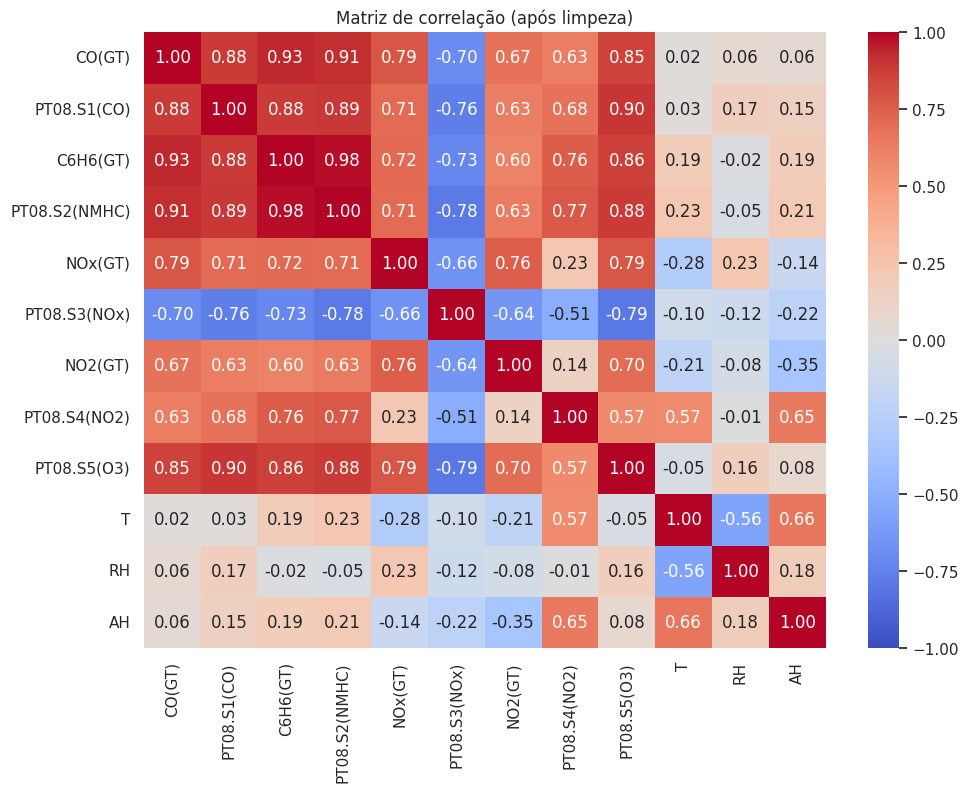

In [11]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    df_clean.drop(columns=['DateTime']).corr(),
    annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
)
plt.title('Matriz de correlação (após limpeza)')
plt.show()

### c) Preparação dos dados

Separa `X` (preditoras) e `y = CO(GT)`. `DateTime` é descartada — o modelo é estático e não usa janelas temporais.

In [12]:
FEATURES = [
    'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
    'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH',
]
TARGET = 'CO(GT)'

X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (5552, 11) | Teste: (1389, 11)


### d) e) Treino, comparação e avaliação

Treinamos 5 regressores. Os baseados em distância/escala usam `StandardScaler` dentro de um `Pipeline`. Avaliamos em holdout (MAE, MSE, RMSE, R²) e por CV de 5 folds (R²) para verificar generalização.

In [13]:
def build_candidates() -> dict[str, Pipeline]:
    return {
        'LinearRegression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LinearRegression()),
        ]),
        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsRegressor(n_neighbors=7)),
        ]),
        'RandomForest': Pipeline([
            ('model', RandomForestRegressor(
                n_estimators=200, max_depth=18, min_samples_leaf=2,
                random_state=RANDOM_STATE, n_jobs=-1,
            )),
        ]),
        'ExtraTrees': Pipeline([
            ('model', ExtraTreesRegressor(
                n_estimators=200, max_depth=18, min_samples_leaf=2,
                random_state=RANDOM_STATE, n_jobs=-1,
            )),
        ]),
        'GradientBoosting': Pipeline([
            ('model', GradientBoostingRegressor(
                n_estimators=400, max_depth=4, learning_rate=0.05,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def evaluate(name: str, pipe: Pipeline) -> dict:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return {
        'Modelo': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2_test': r2,
        'R2_cv_mean': cv_r2.mean(),
        'R2_cv_std': cv_r2.std(),
    }


candidates = build_candidates()
results = [evaluate(name, pipe) for name, pipe in candidates.items()]
results_df = (
    pd.DataFrame(results)
    .sort_values('R2_test', ascending=False)
    .reset_index(drop=True)
)
results_df.round(4)

,Modelo,MAE,MSE,RMSE,R2_test,R2_cv_mean,R2_cv_std
0,ExtraTrees,0.2310,0.1365,0.3694,0.9277,0.9245,0.0115
1,RandomForest,0.2313,0.1390,0.3728,0.9264,0.9208,0.0136
2,KNN,0.2441,0.1399,0.3740,0.9259,0.9168,0.0115
3,GradientBoosting,0.2434,0.1429,0.3781,0.9243,0.9217,0.0142
4,LinearRegression,0.2584,0.1582,0.3978,0.9162,0.9073,0.0145


Melhor modelo: ExtraTrees


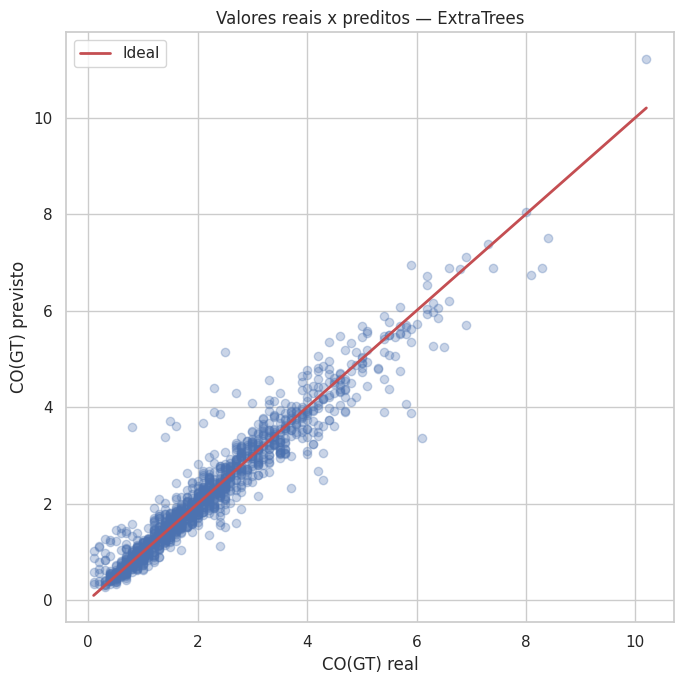

In [14]:
best_name = results_df.iloc[0]['Modelo']
best_pipe = candidates[best_name]
print(f'Melhor modelo: {best_name}')

y_pred_best = best_pipe.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r-', linewidth=2, label='Ideal')
plt.xlabel('CO(GT) real')
plt.ylabel('CO(GT) previsto')
plt.title(f'Valores reais x preditos — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

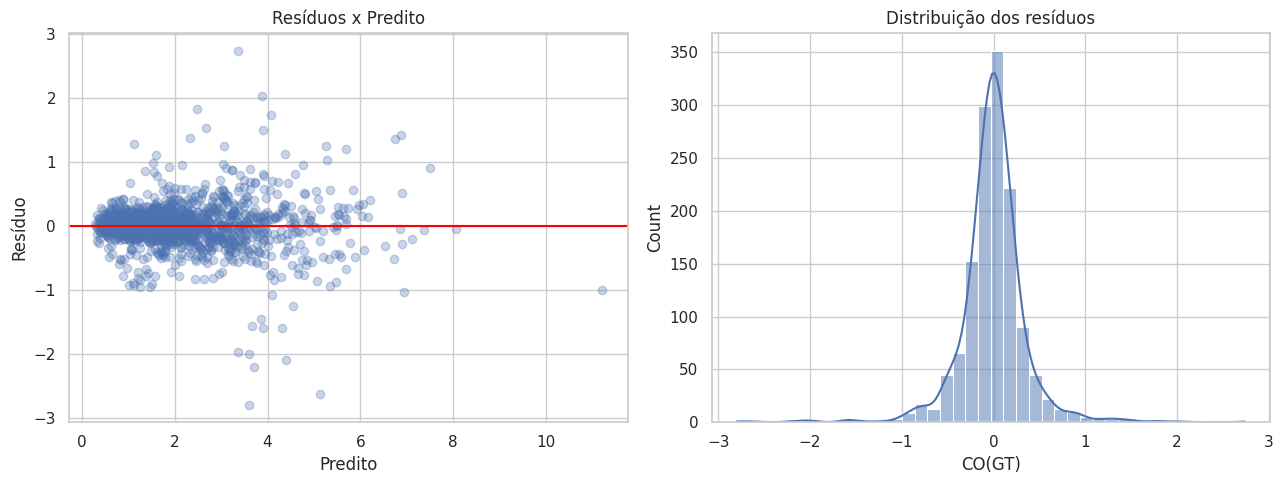

In [15]:
# Análise de resíduos — identifica viés sistemático
residuals = y_test - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.3)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Resíduo')
axes[0].set_title('Resíduos x Predito')
sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Distribuição dos resíduos')
plt.tight_layout()
plt.show()

### f) Justificativa da escolha

Os modelos baseados em árvore (ExtraTrees, RandomForest, GradientBoosting) dominam em R² tanto no conjunto de teste quanto na validação cruzada de 5 folds. A proximidade entre `R2_test` e `R2_cv_mean` (desvio-padrão baixo) indica que o modelo escolhido generaliza sem overfitting relevante. A regressão linear serve de baseline; sua diferença para os ensembles evidencia não-linearidades entre os sensores `PT08.*` e `CO(GT)`.

A escolha final (`best_pipe`) é feita programaticamente pela maior R² de teste, com desempate implícito pela estabilidade em CV.

## Questão 2 — Exportação do Modelo

Exportamos o **pipeline inteiro** (`scaler + estimador`) em `.pkl`. Dessa forma a API na camada de serving não precisa aplicar pré-processamento manualmente — basta passar o vetor de features na ordem correta e chamar `.predict()`.

In [16]:
MODEL_DIR = Path('..') / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / 'modelo.pkl'

artifact = {
    'model': best_pipe,
    'features': FEATURES,
    'target': TARGET,
    'model_name': best_name,
    'metrics': results_df.iloc[0].to_dict(),
}
joblib.dump(artifact, MODEL_PATH)
print(f'Modelo salvo em: {MODEL_PATH.resolve()}')
print(f'Tamanho: {MODEL_PATH.stat().st_size / 1e6:.2f} MB')

Modelo salvo em: /home/samuka7abr/VSCODE/IDP/5_semestre/IDP-ML-2026.1/A1/Av1/projeto/models/modelo.pkl
Tamanho: 65.17 MB


In [17]:
# Sanity check: reload e predição
loaded = joblib.load(MODEL_PATH)
sample = X_test.iloc[[0]]
print('Features esperadas:', loaded['features'])
print('Modelo:', loaded['model_name'])
print('Predição de sanity:', loaded['model'].predict(sample)[0])
print('Valor real:', y_test.iloc[0])

Features esperadas: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Modelo: ExtraTrees
Predição de sanity: 3.009714850657169
Valor real: 2.8


---

As questões 3, 4 e 5 (API Flask, contêiner e documentação) estão na raiz do projeto — ver `../app.py`, `../Dockerfile`, `../docker-compose.yml`, `../README.md` e a pasta `../src/` com a arquitetura em camadas (Clean Architecture + SOLID).